**ФЕДЕРАЛЬНОЕ АГЕНСТВО ЖЕЛЕЗНОДОРОЖНОГО ТРАНСПОРТА**

Федеральное государственное бюджетное образовательное учреждение высшего образования

«ПЕТЕРБУРГСКИЙ ГОСУДАРСТВЕННЫЙ УНИВЕРСИТЕТ ПУТЕЙ СООБЩЕНИЯ Императора Александра I»

---

**Кафедра «Информационные и вычислительные системы»**

Дисциплина «Архитектура вычислительных систем»

**ОТЧЁТ**

**ПО ЛАБОРАТОРНОЙ РАБОТЕ №6**

**«Моделирование и расчёт характеристик параллельных программ»**

---

Выполнил студент

Факультет: АИТ

Группа: ИВБ-211

А. Шефнер

---

Проверил:

доц. каф. "ИВС"

В.А. Гончаренко

# Цель занятия

получение практических навыков построения моделей параллельных алгоритмов и расчета характеристик параллельных программ.

# Ход работы

Импорты для всего блокнота

In [1]:
import dataclasses
import math
import random
from dataclasses import dataclass, is_dataclass

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import HTML
from matplotlib.patches import FancyArrowPatch

Функции отображения табличных данных

In [2]:
def render_cell(cell):
    if cell is None:
        cell = "-"
    return f"        <td>{cell}</td>\n"


def display_table_lists(data, headers=None):
    result = "<table>\n"

    if headers:
        result += "  <thead>\n"
        result += "    <tr>\n"
        for header in headers:
            result += f"      <th>{header}</th>"
        result += "    </tr>\n"
        result += "  </thead>\n"

    result += "  <tbody>\n"
    for row in data:
        result += "    <tr>\n"

        if is_dataclass(row):
            for key, value in dataclasses.asdict(row).items():
                result += render_cell(value)
        else:
            for cell in row:
                result += render_cell(cell)

        result += "    </tr>\n"
    result += "  </tbody>\n"
    result += "</table>\n"
    display(HTML(result))


def display_table_dicts(data, headers=None):
    keys = list(data[0].keys())
    data = [[dic[key] for key in dic] for dic in data]
    headers = headers if headers else keys
    display_table_lists(data, headers)


def display_table_dataclasses(data, headers=None):
    display_table_dicts([dataclasses.asdict(obj) for obj in data], headers)


def display_table(data, headers=None):
    first = data[0]
    if isinstance(first, list):
        display_table_lists(data, headers)
    elif isinstance(first, dict):
        display_table_dicts(data, headers)
    elif is_dataclass(first):
        display_table_dataclasses(data, headers)
    else:
        raise ValueError("Unsupported type")

## Исходные данные по варианту

$$
    \sum_{k=1}^3 \frac{1}{(2k + 1)^2}
$$

## Финальный вид операции

$$
    \frac{1}{(2 \cdot 1 + 1)^2} +
    \frac{1}{(2 \cdot 2 + 1)^2} +
    \frac{1}{(2 \cdot 3 + 1)^2}
$$

## Таблица со списком операций и временем выполнения

|№ |         Содержание        |Время|
|--|---------------------------|-----|
|1 |$X_1    := 2 \cdot 1$      |  2  |
|2 |$X_2    := X_1 + 1$        |  1  |
|3 |$X_3    := X_2^2$          |  2  |
|4 |$X_4    := 1 / X_3$        |  4  |
|5 |$X_5    := 2 \cdot 2$      |  2  |
|6 |$X_6    := X_5 + 1$        |  1  |
|7 |$X_7    := X_6^2$          |  2  |
|8 |$X_8    := 1 / X_7$        |  4  |
|9 |$X_9    := 2 \cdot 3$      |  2  |
|10|$X_{10} := X_9 + 1$        |  1  |
|11|$X_{11} := X_{10}^2$       |  2  |
|12|$X_{12} := 1 / X_{11}$     |  4  |
|13|$X_{13} := X_4 + X_8$      |  1  |
|14|$X_{14} := X_{13} + X_{12}$|  1  |

## ЯПФ графа задачи

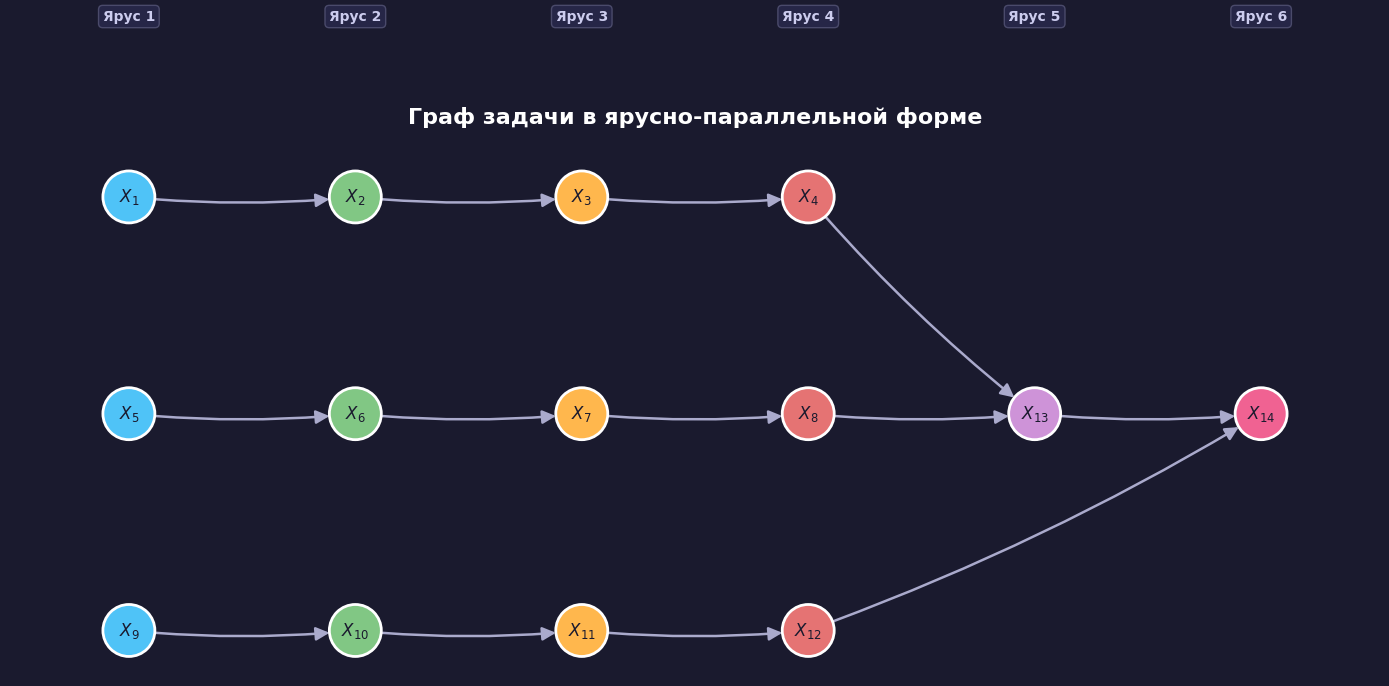

In [3]:
edges = [
    (1, 2),
    (2, 3),
    (3, 4),
    (5, 6),
    (6, 7),
    (7, 8),
    (9, 10),
    (10, 11),
    (11, 12),
    (4, 13),
    (8, 13),
    (13, 14),
    (12, 14),
]

G = nx.DiGraph()
G.add_nodes_from(range(1, 15))
G.add_edges_from(edges)

layers = {
    # Tier 1: independent constants
    1: 0,
    5: 0,
    9: 0,
    2: 1,
    6: 1,
    # Tier 2: +1
    10: 1,
    3: 2,
    7: 2,
    # Tier 3: square
    11: 2,
    4: 3,
    8: 3,
    # Tier 4: 1/x
    12: 3,
    # Tier 5: X4 + X8
    13: 4,
    # Tier 6: X13 + X12
    14: 5,
}

tier_nodes = {}
for node, layer in layers.items():
    tier_nodes.setdefault(layer, []).append(node)

pos = {}
for layer, nodes in tier_nodes.items():
    nodes_sorted = sorted(nodes)
    n = len(nodes_sorted)
    for i, node in enumerate(nodes_sorted):
        y = (n - 1) / 2 - i
        pos[node] = (layer * 2.5, y * 2)

tier_colors = {
    0: "#4FC3F7",
    1: "#81C784",
    2: "#FFB74D",
    3: "#E57373",
    4: "#CE93D8",
    5: "#F06292",
}
node_colors = [tier_colors[layers[n]] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
    edge_color="#aaaacc",
    width=1.8,
    connectionstyle="arc3,rad=0.05",
    node_size=1400,
)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=1400,
    linewidths=2,
    edgecolors="white",
)

labels = {n: f"$X_{{{n}}}$" for n in G.nodes()}
nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    ax=ax,
    font_size=12,
    font_color="#1a1a2e",
    font_weight="bold",
)

for layer, nodes in tier_nodes.items():
    x = layer * 2.5
    ax.text(
        x,
        3.6,
        f"Ярус {layer + 1}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#ccccee",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="#2a2a4e",
            edgecolor="#555577",
            alpha=0.8,
        ),
    )

ax.set_title(
    "Граф задачи в ярусно-параллельной форме",
    fontsize=16,
    color="white",
    fontweight="bold",
    pad=20,
)
ax.axis("off")

plt.tight_layout()
plt.show()

## Матрица смежности графа

|        |$X_1$|$X_2$|$X_3$|$X_4$|$X_5$|$X_6$|$X_7$|$X_8$|$X_9$|$X_{10}$|$X_{11}$|$X_{12}$|$X_{13}$|$X_{14}$|
|--------|-----|-----|-----|-----|-----|-----|-----|-----|-----|--------|--------|--------|--------|--------|
|$X_1$   |  0  |  1  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   0    |
|$X_2$   |  0  |  0  |  1  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   0    |
|$X_3$   |  0  |  0  |  0  |  1  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   0    |
|$X_4$   |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   1    |   0    |
|$X_5$   |  0  |  0  |  0  |  0  |  0  |  1  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   0    |
|$X_6$   |  0  |  0  |  0  |  0  |  0  |  0  |  1  |  0  |  0  |   0    |   0    |   0    |   0    |   0    |
|$X_7$   |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  1  |  0  |   0    |   0    |   0    |   0    |   0    |
|$X_8$   |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   1    |   0    |
|$X_9$   |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   1    |   0    |   0    |   0    |   0    |
|$X_{10}$|  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   1    |   0    |   0    |   0    |
|$X_{11}$|  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   1    |   0    |   0    |
|$X_{12}$|  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   1    |
|$X_{13}$|  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   1    |
|$X_{14}$|  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |   0    |   0    |   0    |   0    |   0    |

## Характеристики операций

|№       |1 |2 |3 |4 |5 |6 |7 |8 |9 |10|11|12|13|14|
|--------|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|$t_i$   |2 |1 |2 |4 |2 |1 |2 |4 |2 |1 |2 |4 |1 |1 |
|$T_{рн}$|0 |2 |3 |4 |0 |2 |3 |4 |0 |2 |3 |4 |8 |9 |
|$T_{ро}$|2 |3 |4 |8 |2 |3 |4 |8 |2 |3 |4 |8 |9 |10|
|$T_{по}$|2 |3 |4 |8 |2 |3 |4 |8 |3 |4 |5 |9 |9 |10|
|$T_{пн}$|0 |2 |3 |4 |0 |2 |3 |4 |1 |2 |3 |5 |8 |9 |
|$R$     |0 |0 |0 |0 |0 |0 |0 |0 |1 |1 |1 |1 |0 |0 |

Длина критического пути $T_{кр} = 10$

## Ускорение параллельной обработки

Время последовательного выполнения программы:

$$
    T_{посл.} =
    \sum_{k=i}^{14} X_i =
    2 + 1 + 2 + 4 + 2 + 1 + 2 + 4 + 2 + 1 + 2 + 4 + 1 + 1 =
    29
$$

Предельное ускорение параллельных вычислений:

$$
    S =
    \frac{T_{посл.}}{T_{пар.}} =
    \frac{24}{10} =
    2.4
$$

Эффективность параллельных вычислений:

$$
    E = \frac{S}{n} = \frac{2.4}{3} = 0.8
$$

Стоимость параллельных вычислений:

$$
    C = n \cdot T_{пар.} = 3 \cdot 10 = 30
$$

# Вывод

В ходе лабораторной работы была построена модель параллельного алгоритма вычисления суммы ряда $\sum_{k=1}^3 \frac{1}{(2k+1)^2}$ в виде графа задачи в ярусно-параллельной форме, содержащего 14 операций и 6 ярусов. На основе анализа графа были рассчитаны основные характеристики параллельной программы: критический путь составил $T_{кр} = 10$, время последовательного выполнения — $T_{посл} = 29$, предельное ускорение при использовании 3 процессоров — $S = \frac{T_{посл}}{T_{пар}} = \frac{29}{10} = 2.4$, эффективность — $E = \frac{S}{n} = \frac{2.4}{3} = 0.8$, а стоимость параллельных вычислений — $C = n \cdot T_{пар} = 3 \cdot 10 = 30$. Полученные результаты свидетельствуют о достаточно высокой эффективности распараллеливания ($E = 0.8$, то есть 80%), что объясняется хорошей независимостью трёх ветвей вычислений, соответствующих трём слагаемым суммы, и минимальным числом операций с зависимостями по данным.